# Explicabilidad en LLMs Locales: Integrated Gradients desde Cero

Este notebook implementa **Integrated Gradients (IG)** para un modelo de lenguaje de Hugging Face. A diferencia de métodos agnósticos al modelo que perturban la entrada (como LIME o KernelSHAP), IG aprovecha el acceso a los pesos internos de la red neuronal para calcular la atribución exacta mediante el teorema fundamental del cálculo.

La fórmula que aproximaremos mediante una suma de Riemann es:
$$IG_i(x) = (x_i - x'_i) \times \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x-x'))}{\partial x_i} d\alpha$$

Donde $x$ es nuestra entrada real, $x'$ es el baseline (ceros) y $\alpha$ es el factor de interpolación.

In [1]:
# Instalar dependencias si estás en Colab o un entorno nuevo
 #!pip install transformers torch matplotlib seaborn pandas

import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Configuramos visualizaciones
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

/Users/nadiatamayo/miniconda3/envs/deeplearning_curso/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from getpass import getpass
from huggingface_hub import login

hf_token = getpass("Pega tu HF token (input oculto, Enter para omitir): ").strip()
login(token=hf_token, add_to_git_credential=False)

In [3]:
from huggingface_hub import whoami

try:
    user_info = whoami()
    print(f"✓ Autenticado como: {user_info['name']}")
    print(f"✓ Token válido")
except Exception as e:
    print(f"✗ Error de autenticación: {e}")
    print("Probablemente el token está vacío o expirado.")

✓ Autenticado como: Nad3045
✓ Token válido


In [4]:
import os, time

# Modelo pequeno y estable para sentimiento (2 clases)
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

start = time.perf_counter()
tokenizer = AutoTokenizer.from_pretrained(model_name, token=hf_token)
model = AutoModelForSequenceClassification.from_pretrained(model_name, token=hf_token)
model.eval()

elapsed = time.perf_counter() - start
print(f"✓ Cargado en {elapsed:.1f}s")
print("Clases del modelo:", model.config.id2label)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4300.75it/s]

✓ Cargado en 2.1s
Clases del modelo: {0: 'NEGATIVE', 1: 'POSITIVE'}


In [5]:
inputs = tokenizer("I love this movie", return_tensors="pt")

In [6]:
inputs

{'input_ids': tensor([[ 101, 1045, 2293, 2023, 3185,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

In [7]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Implementación del Algoritmo

A continuación, encapsulamos la lógica en una función reutilizable. El proceso sigue estos pasos:
1. Obtener los IDs de los tokens y los embeddings originales.
2. Crear tensores interpolados entre un vector de ceros y los embeddings originales.
3. Hacer *forward pass* usando `inputs_embeds` y calcular gradientes.
4. Integrar (promediar) los gradientes y multiplicar por la entrada original.

In [8]:
def calcular_ig(texto, clase_objetivo, modelo, tokenizador, m_steps=50, debug=False):
    """
    Calcula Integrated Gradients para una clase objetivo.

    Args:
        texto: Texto de entrada.
        clase_objetivo: Indice de clase que se quiere explicar.
        modelo: Modelo HF de clasificacion.
        tokenizador: Tokenizer HF.
        m_steps: Numero de pasos para aproximar la integral.
        debug: Si True, imprime shapes y valores utiles para entender el flujo.

    Returns:
        tokens: Lista de tokens del texto.
        token_attributions: Importancia por token (magnitud L2, sin signo).
        token_attributions_signed: Atribucion por token con signo.
    """

    # 1) Tokenizar texto y obtener IDs
    inputs = tokenizador(texto, return_tensors="pt")
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]
    tokens = tokenizador.convert_ids_to_tokens(input_ids[0])

    # 2) Convertir IDs a embeddings y crear baseline de ceros
    embeddings_layer = modelo.get_input_embeddings()
    input_embeddings = embeddings_layer(input_ids).detach()
    baseline_embeddings = torch.zeros_like(input_embeddings)

    if debug:
        print("=== DEBUG IG ===")
        print(f"Texto: {texto}")
        print(f"Clase objetivo: {clase_objetivo} -> {modelo.config.id2label.get(clase_objetivo, clase_objetivo)}")
        print(f"input_ids shape: {tuple(input_ids.shape)}")
        print(f"tokens: {tokens}")
        print(f"attention_mask shape: {tuple(attention_mask.shape)}")
        print(f"input_embeddings shape: {tuple(input_embeddings.shape)}")
        print(f"baseline_embeddings shape: {tuple(baseline_embeddings.shape)}")
        print(f"m_steps: {m_steps}")

    # 3) Interpolar entre baseline (alpha=0) y entrada real (alpha=1)
    interpolated_embeddings = [
        baseline_embeddings + (i / m_steps) * (input_embeddings - baseline_embeddings)
        for i in range(m_steps + 1)
    ]
    print(f"Interpolated embeddings: {len(interpolated_embeddings)} steps, each shape: {tuple(interpolated_embeddings[0].shape)}")
    print(interpolated_embeddings[0][0][:5])  # Mostrar los primeros 5 valores del primer token del primer paso
    gradients = []

    # 4) Para cada punto interpolado, calcular gradiente del score objetivo
    for emb in interpolated_embeddings:
        emb = emb.clone().detach().requires_grad_(True)
        modelo.zero_grad()

        # Pasamos tambien attention_mask para consistencia con el forward normal
        outputs = modelo(inputs_embeds=emb, attention_mask=attention_mask)
        score = outputs.logits[0, clase_objetivo]

        score.backward()
        gradients.append(emb.grad.clone())

    # 5) Aproximar la integral promedio de gradientes
    stacked_gradients = torch.stack(gradients)  # (m_steps+1, batch, seq_len, hidden)
    avg_gradients = torch.mean(stacked_gradients, dim=0)  # (batch, seq_len, hidden)

    # 6) IG = (input - baseline) * gradiente_promedio
    integrated_gradients = (input_embeddings - baseline_embeddings) * avg_gradients

    # 7) Reducir dimension de embedding a 1 score por token
    # - con signo: suma sobre hidden
    # - sin signo: norma L2 sobre hidden
    token_attributions_signed = integrated_gradients.sum(dim=-1).squeeze().detach().cpu().numpy()
    token_attributions = torch.norm(integrated_gradients, dim=-1).squeeze().detach().cpu().numpy()

    if debug:
        print(f"stacked_gradients shape: {tuple(stacked_gradients.shape)}")
        print(f"avg_gradients shape: {tuple(avg_gradients.shape)}")
        print(f"integrated_gradients shape: {tuple(integrated_gradients.shape)}")
        print(f"token_attributions shape: {tuple(token_attributions.shape)}")
        print(f"token_attributions_signed shape: {tuple(token_attributions_signed.shape)}")
        print(f"Num tokens: {len(tokens)}")
        print("================")

    return tokens, token_attributions, token_attributions_signed

## Análisis caso negativo

In [9]:
# Probemos con una frase de ejemplo
texto_prueba_negativo = "The product arrived quickly, but the quality is absolutely terrible and it doesn't work"

In [10]:
# En este modelo: 0 = NEGATIVE, 1 = POSITIVE
clase_analizar = 0
print(f"Analizando atribución para la clase: {model.config.id2label[clase_analizar]}")

tokens, attributions, attributions_signed = calcular_ig(
    texto=texto_prueba_negativo,
    clase_objetivo=clase_analizar,
    modelo=model,
    tokenizador=tokenizer,
    m_steps=50,
    debug=True
)

Analizando atribución para la clase: NEGATIVE
=== DEBUG IG ===
Texto: The product arrived quickly, but the quality is absolutely terrible and it doesn't work
Clase objetivo: 0 -> NEGATIVE
input_ids shape: (1, 19)
tokens: ['[CLS]', 'the', 'product', 'arrived', 'quickly', ',', 'but', 'the', 'quality', 'is', 'absolutely', 'terrible', 'and', 'it', 'doesn', "'", 't', 'work', '[SEP]']
attention_mask shape: (1, 19)
input_embeddings shape: (1, 19, 768)
baseline_embeddings shape: (1, 19, 768)
m_steps: 50
Interpolated embeddings: 51 steps, each shape: (1, 19, 768)
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
stacked_gradients shape: (51, 1, 19, 768)
avg_gradients shape: (1, 19, 768)
integrated_gradients shape: (1, 19, 768)
token_attributions shape: (19,)
token_attributions_signed shape: (19,)
Num tokens: 19


In [11]:
# Limpiamos un poco los tokens especiales de subword para la grafica
clean_tokens = [t.replace("Ġ", "").replace("##", "") for t in tokens]

# Crear un DataFrame con atribucion sin signo y con signo por token
df_attr = pd.DataFrame({
    "Token": clean_tokens,
    "Importancia": attributions,
    "Importancia_signed": attributions_signed
})
print(df_attr)

         Token  Importancia  Importancia_signed
0        [CLS]     0.027958            0.040868
1          the     0.025067            0.038604
2      product     0.097031           -0.015935
3      arrived     0.091831           -0.002704
4      quickly     0.072394            0.156793
5            ,     0.026133            0.006587
6          but     0.049584           -0.017621
7          the     0.041559           -0.043177
8      quality     0.092011            0.074000
9           is     0.042300           -0.082655
10  absolutely     0.147870            0.009845
11    terrible     0.213823            0.179030
12         and     0.040554            0.154105
13          it     0.050337            0.299572
14       doesn     0.083412            0.369729
15           '     0.053539            0.349480
16           t     0.108847            0.528810
17        work     0.109112            0.364000
18       [SEP]     0.056633            0.370719


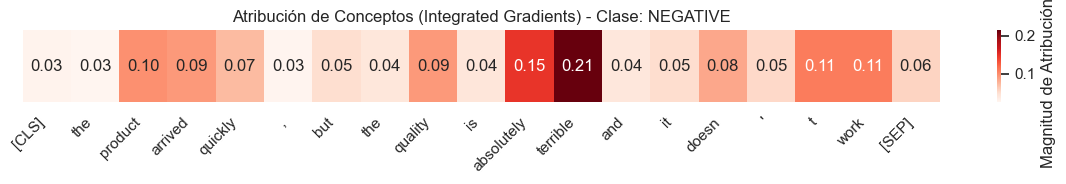

In [12]:


# Graficar un mapa de calor (Heatmap) horizontal
plt.figure(figsize=(12, 2))
sns.heatmap(
    data=[df_attr["Importancia"].values],
    xticklabels=df_attr["Token"].values,
    yticklabels=False,
    cmap="Reds",
    cbar_kws={"label": "Magnitud de Atribución (IG)"},
    annot=True,
    fmt=".2f"
)
plt.title(f"Atribución de Conceptos (Integrated Gradients) - Clase: {model.config.id2label[clase_analizar]}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Análisis caso positivo

In [13]:
texto_prueba_positivo= "I absolutely love this product! It works perfectly and the quality is amazing."

In [14]:
# En este modelo: 0 = NEGATIVE, 1 = POSITIVE
clase_analizar = 1
print(f"Analizando atribución para la clase: {model.config.id2label[clase_analizar]}")

tokens, attributions, attributions_signed = calcular_ig(
    texto=texto_prueba_positivo,
    clase_objetivo=clase_analizar,
    modelo=model,
    tokenizador=tokenizer,
    m_steps=50,
    debug=True
)

Analizando atribución para la clase: POSITIVE
=== DEBUG IG ===
Texto: I absolutely love this product! It works perfectly and the quality is amazing.
Clase objetivo: 1 -> POSITIVE
input_ids shape: (1, 17)
tokens: ['[CLS]', 'i', 'absolutely', 'love', 'this', 'product', '!', 'it', 'works', 'perfectly', 'and', 'the', 'quality', 'is', 'amazing', '.', '[SEP]']
attention_mask shape: (1, 17)
input_embeddings shape: (1, 17, 768)
baseline_embeddings shape: (1, 17, 768)
m_steps: 50
Interpolated embeddings: 51 steps, each shape: (1, 17, 768)
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
stacked_gradients shape: (51, 1, 17, 768)
avg_gradients shape: (1, 17, 768)
integrated_gradients shape: (1, 17, 768)
token_attributions shape: (17,)
token_attributions_signed shape: (17,)
Num tokens: 17


In [15]:
# Limpiamos un poco los tokens especiales de subword para la grafica
clean_tokens = [t.replace("Ġ", "").replace("##", "") for t in tokens]

# Crear un DataFrame con atribucion sin signo y con signo por token
df_atrr_positive = pd.DataFrame({
    "Token": clean_tokens,
    "Importancia": attributions,
    "Importancia_signed": attributions_signed
})
print(df_atrr_positive)

         Token  Importancia  Importancia_signed
0        [CLS]     0.031515            0.032540
1            i     0.060789            0.263324
2   absolutely     0.171301            0.634608
3         love     0.103875            0.529139
4         this     0.086843            0.517732
5      product     0.184540            0.627204
6            !     0.089919            0.049141
7           it     0.085169            0.448729
8        works     0.132567            0.446843
9    perfectly     0.189024            0.530659
10         and     0.041125            0.143848
11         the     0.045179            0.305869
12     quality     0.156497            0.147717
13          is     0.054312            0.038037
14     amazing     0.131197            0.531450
15           .     0.082936            0.126772
16       [SEP]     0.095145            0.987969


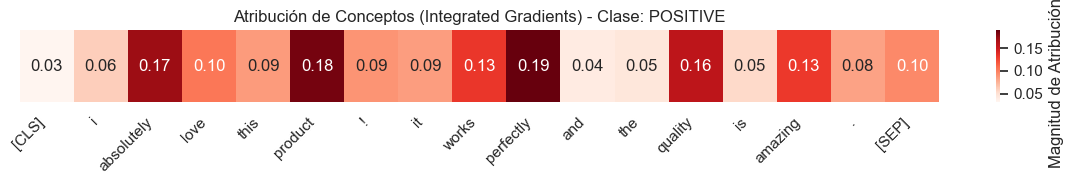

In [16]:


# Graficar un mapa de calor (Heatmap) horizontal
plt.figure(figsize=(12, 2))
sns.heatmap(
    data=[df_atrr_positive["Importancia"].values],
    xticklabels=df_atrr_positive["Token"].values,
    yticklabels=False,
    cmap="Reds",
    cbar_kws={"label": "Magnitud de Atribución (IG)"},
    annot=True,
    fmt=".2f"
)
plt.title(f"Atribución de Conceptos (Integrated Gradients) - Clase: {model.config.id2label[clase_analizar]}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Validación con Librerías de Producción (Captum)

Escribir el algoritmo desde cero es excelente para entender la teoría, pero en un entorno de producción necesitamos herramientas optimizadas. **Captum**, la librería oficial de interpretabilidad de PyTorch, nos ofrece implementaciones robustas de Integrated Gradients.

A continuación, usaremos `LayerIntegratedGradients` de Captum para calcular las atribuciones y compararlas con nuestro código manual. Notarás que Captum maneja automáticamente la creación del baseline y la aproximación de la integral.

In [23]:
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz

# 1. Preparar la entrada
texto_prueba = "The product arrived quickly, but the quality is absolutely terrible and it doesn't work."
clase_analizar = 0  # Analizar la clase NEGATIVE
inputs = tokenizer(texto_prueba, return_tensors="pt")
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# 2. Definir una función wrapper para el forward pass
# Captum llamará esta función con input_ids y argumentos adicionales
def forward_func(input_ids, attention_mask):
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.logits

# 3. Inicializar LayerIntegratedGradients sobre la capa de embeddings
capa_embeddings = model.get_input_embeddings()
lig = LayerIntegratedGradients(forward_func, capa_embeddings)


In [24]:

# 4. Calcular la atribución
attributions, delta = lig.attribute(
    inputs=input_ids,
    additional_forward_args=(attention_mask,),
    target=clase_analizar,
    n_steps=50,
    return_convergence_delta=True
)

# 5. Condensar valores por token con norma L2 (consistente con la version manual)
# attributions shape: (1, num_tokens, embedding_dim)
attributions_norm = torch.norm(attributions, dim=-1).squeeze(0).detach().numpy()

print(f"Error de convergencia (Delta): {delta.item():.4f}")


Error de convergencia (Delta): -0.6215


In [25]:
# Visualización ANTES de la optimización dinámica (n_steps fijo)
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace('Ġ', '') for t in tokens]

# Atribuciones con signo (no norma) para conservar dirección de contribución
attributions_signed = attributions.sum(dim=-1).squeeze(0)
scale = torch.max(torch.abs(attributions_signed)).clamp(min=1e-8)

# Captum pinta verde = a favor de attr_class; invertimos si quieres rojo para palabras negativas
invertir_colores = True
if invertir_colores:
    attributions_vis = (-attributions_signed / scale).detach().cpu().numpy()
else:
    attributions_vis = (attributions_signed / scale).detach().cpu().numpy()

with torch.no_grad():
    logits = model(input_ids).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    prob_objetivo = probs[0, clase_analizar].item()

score_vis = viz.VisualizationDataRecord(
    word_attributions=attributions_vis,
    pred_prob=prob_objetivo,
    pred_class=model.config.id2label[clase_analizar],
    true_class=model.config.id2label[clase_analizar],
    attr_class=model.config.id2label[clase_analizar],
    attr_score=attributions_signed.sum().item(),
    raw_input_ids=clean_tokens,
    convergence_score=delta.item()
)

print("Comparativa visual ANTES de optimización:")
_ = viz.visualize_text([score_vis])

Comparativa visual ANTES de optimización:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
NEGATIVE,NEGATIVE (1.00),NEGATIVE,3.01,"[CLS] the product arrived quickly , but the quality is absolutely terrible and it doesn ' t work . [SEP]"


In [26]:
# Si estás usando Captum:
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace("Ġ", "").replace("##", "") for t in tokens]

# Atribución con signo por token (recomendada)
attr_token = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

df_token_attr = pd.DataFrame({
    "token": clean_tokens,
    "atribucion": attr_token
})

display(df_token_attr)

,token,atribucion
0,[CLS],-0.067333
1,the,-0.000080
2,product,0.147253
3,arrived,0.013854
4,quickly,0.113235
5,",",-0.023373
6,but,-0.050183
7,the,-0.057710
8,quality,0.157014
9,is,-0.094104


In [27]:
print("Iniciando búsqueda dinámica de convergencia...")
print("-" * 55)

# Configuración inicial
umbral_tolerancia = 0.05
m_actual = 50
paso_incremento = 50
max_pasos = 500 # Límite de seguridad para no fundir la memoria RAM/VRAM

# Inicializamos el delta con un valor muy alto para que entre al bucle
delta_actual = float('inf') 

while abs(delta_actual) > umbral_tolerancia and m_actual <= max_pasos:
    print(f"Probando con m = {m_actual}...")
    
    # Calculamos la atribución usando Captum
    attributions, delta = lig.attribute(
        inputs=input_ids,
        target=clase_analizar,
        n_steps=m_actual,
        return_convergence_delta=True,
        additional_forward_args=(attention_mask,)
    )
    
    delta_actual = delta.item()
    print(f"  -> Delta obtenido: {delta_actual:.4f}")
    
    # Si aún no cumple la condición, aumentamos m
    if abs(delta_actual) > umbral_tolerancia:
        m_actual += paso_incremento

# Evaluación del resultado final
print("-" * 55)
if abs(delta_actual) <= umbral_tolerancia:
    print(f" Convergencia exitosa, Se alcanzó un Delta de {delta_actual:.4f} usando {m_actual} pasos.")
else:
    print(f" Límite computacional alcanzado ({max_pasos} pasos). El Delta final fue {delta_actual:.4f}.")


Iniciando búsqueda dinámica de convergencia...
-------------------------------------------------------
Probando con m = 50...
  -> Delta obtenido: -0.6215
Probando con m = 100...
  -> Delta obtenido: 0.0355
-------------------------------------------------------
 Convergencia exitosa, Se alcanzó un Delta de 0.0355 usando 100 pasos.


In [28]:
# Preparar los tokens y la predicción para la visualización
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
clean_tokens = [t.replace('Ġ', '') for t in tokens]

# Usar atribuciones con signo (NO norma) para que haya valores positivos y negativos
# attributions shape: (1, num_tokens, embedding_dim)
attributions_signed = attributions.sum(dim=-1).squeeze(0)

# Escalado para mejorar contraste visual en Captum
scale = torch.max(torch.abs(attributions_signed)).clamp(min=1e-8)

# Captum pinta verde = a favor de attr_class.
# Si quieres ver "terrible" en rojo cuando attr_class=NEGATIVE, invierte colores.
invertir_colores = True
if invertir_colores:
    attributions_vis = (-attributions_signed / scale).detach().cpu().numpy()
else:
    attributions_vis = (attributions_signed / scale).detach().cpu().numpy()

# Obtener la probabilidad real de la clase predecida
with torch.no_grad():
    logits = model(input_ids).logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    prob_objetivo = probs[0, clase_analizar].item()

# Crear el registro de visualización
score_vis = viz.VisualizationDataRecord(
    word_attributions=attributions_vis,
    pred_prob=prob_objetivo,
    pred_class=model.config.id2label[clase_analizar],
    true_class=model.config.id2label[clase_analizar],  # Asumimos que la predicción es correcta para el ejemplo
    attr_class=model.config.id2label[clase_analizar],
    attr_score=attributions_signed.sum().item(),
    raw_input_ids=clean_tokens,
    convergence_score=delta.item()
)

# Mostrar la tabla HTML
print("Comparativa visual generada por Captum:")
_ = viz.visualize_text([score_vis])

Comparativa visual generada por Captum:


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
NEGATIVE,NEGATIVE (1.00),NEGATIVE,3.67,"[CLS] the product arrived quickly , but the quality is absolutely terrible and it doesn ' t work . [SEP]"
